1. AWS NAB 데이터 다운로드 및 AI 학습 데이터 전처리

⏳ 실전 AWS 클라우드 데이터(NAB) 로드 및 전처리 시작...


C:\Users\watmx\AppData\Local\Temp\ipykernel_9652\2452089937.py:19: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df.resample('1S').interpolate(method='linear')


✅ 전처리 완료! 학습 데이터(X_train) 형태: (967436, 5, 3)


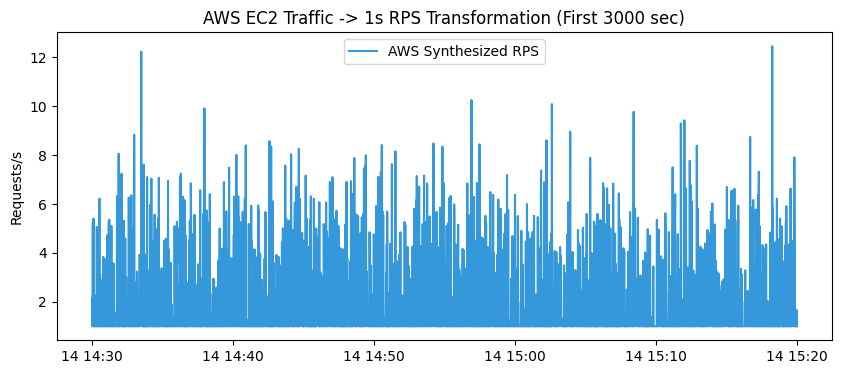

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import joblib
import matplotlib.pyplot as plt

print("⏳ 실전 AWS 클라우드 데이터(NAB) 로드 및 전처리 시작...")

# 1. NAB 깃허브에서 AWS EC2 트래픽(CPU/Network) 스파이크 데이터 직접 다운로드
url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv"
df = pd.read_csv(url)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# 2. 클라우드 지표(0~100)를 우리 프로젝트의 트래픽(RPS) 스케일로 변환 (최대 500 RPS 수준)
df['Requests/s'] = df['value'] * 5 

# 3. 1초 단위(1S) 리샘플링 및 보간 (5분 단위 데이터를 1초 단위로 쪼개기)
df_1s = df.resample('1S').interpolate(method='linear')

# 현실감을 위해 1초 단위의 미세한 트래픽 노이즈(들쭉날쭉함) 추가
np.random.seed(42)
noise = np.random.normal(0, 3, len(df_1s))
df_1s['Requests/s'] = np.clip(df_1s['Requests/s'] + noise, 1, None) # 트래픽이 0 이하로 안 내려가게 방어

# 4. [핵심] 가상의 스파이크 응답시간 합성 (기존 1.5제곱 공식 그대로 적용)
df_1s['Total Average Response Time'] = 100 + (df_1s['Requests/s'] ** 1.5) * 0.5
df_1s.fillna(0, inplace=True)

# 유저 수는 RPS에 비례하도록 가상 설정 (기존 코드 호환을 위함)
df_1s['User Count'] = (df_1s['Requests/s'] * 0.8).astype(int)

# 5. 정규화 (MinMaxScaler)
scaler = MinMaxScaler()
# AI 입력 피처: ['User Count', 'Requests/s', 'Total Average Response Time']
scaled_data = scaler.fit_transform(df_1s[['User Count', 'Requests/s', 'Total Average Response Time']])

# 나중에 FastAPI 서버에서 쓸 수 있게 Scaler 덮어쓰기 저장
joblib.dump(scaler, 'aws_kaggle_scaler.pkl')

# 6. 시계열 윈도우 생성 (과거 5초를 보고 다음 1초의 지연시간을 예측)
look_back = 5
X, y = [], []
for i in range(len(scaled_data) - look_back):
    X.append(scaled_data[i:(i + look_back), :])
    y.append(scaled_data[i + look_back, 2]) # 2번 인덱스가 Response Time

X = np.array(X)
y = np.array(y)

# 데이터 분할 (Train 80%, Test 20%)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"✅ 전처리 완료! 학습 데이터(X_train) 형태: {X_train.shape}")

# 7. 변환된 AWS 트래픽의 스파이크 형태 시각화 확인
plt.figure(figsize=(10, 4))
plt.plot(df_1s.index[:3000], df_1s['Requests/s'][:3000], color='#3498db', label='AWS Synthesized RPS')
plt.title('AWS EC2 Traffic -> 1s RPS Transformation (First 3000 sec)')
plt.ylabel('Requests/s')
plt.legend()
plt.show()

2. 단일 모델 비교 LSTM vs GRU , 둘을 합친 하이브리드 앙상블 모델 비교

[시스템] 딥러닝 최적 가중치 탐색 및 학습 곡선 추출을 시작합니다.

[Model: LSTM] - 3회 반복 학습 및 통계적 검증 진행
  - Iteration 1/3 | Val Loss: 0.002616 | Train Time: 57.21s
  - Iteration 2/3 | Val Loss: 0.002618 | Train Time: 19.87s
  - Iteration 3/3 | Val Loss: 0.002617 | Train Time: 19.83s
  => 최적 가중치 모델 추출 및 저장 완료: lstm_model.keras (Best Loss: 0.002616)

[Model: GRU] - 3회 반복 학습 및 통계적 검증 진행
  - Iteration 1/3 | Val Loss: 0.002619 | Train Time: 20.81s
  - Iteration 2/3 | Val Loss: 0.002617 | Train Time: 22.09s
  - Iteration 3/3 | Val Loss: 0.002622 | Train Time: 21.85s
  => 최적 가중치 모델 추출 및 저장 완료: gru_model.keras (Best Loss: 0.002617)

[Model: Ensemble] - 3회 반복 학습 및 통계적 검증 진행
  - Iteration 1/3 | Val Loss: 0.002618 | Train Time: 18.31s
  - Iteration 2/3 | Val Loss: 0.002623 | Train Time: 17.89s
  - Iteration 3/3 | Val Loss: 0.002618 | Train Time: 17.95s
  => 최적 가중치 모델 추출 및 저장 완료: ensemble_model.keras (Best Loss: 0.002618)

[시스템] 학습 완료. 최적 모델의 학습 곡선(그래프)을 생성합니다...


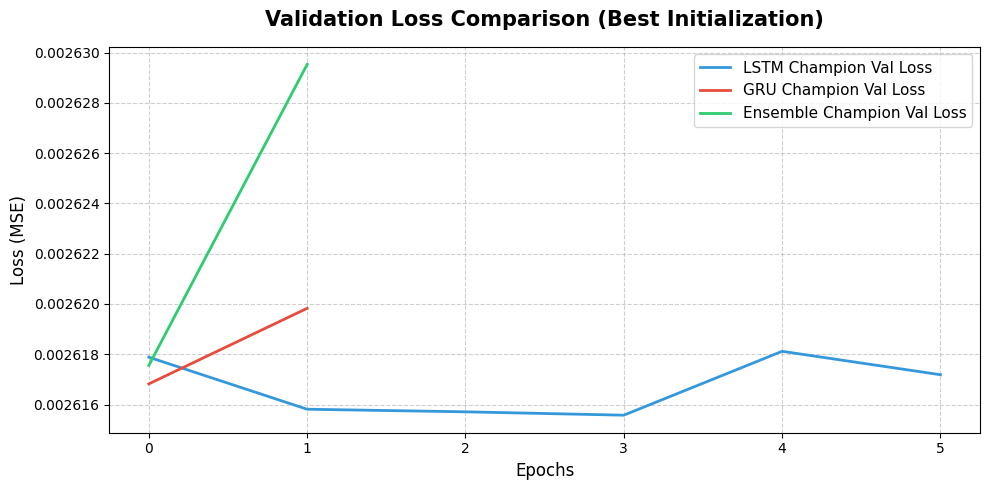


[최종 통계 및 검증 결과 리포트]
[LSTM Model]
 - 추출된 최저 오차 (Best Loss)  : 0.002616
 - 평균 오차 (Mean Loss)         : 0.002617
 - 오차 표준 편차 (Std Dev)      : 0.00000121
 - 1회 추론 속도 (Inference)     : 57.88 ms

[GRU Model]
 - 추출된 최저 오차 (Best Loss)  : 0.002617
 - 평균 오차 (Mean Loss)         : 0.002619
 - 오차 표준 편차 (Std Dev)      : 0.00000205
 - 1회 추론 속도 (Inference)     : 60.92 ms

[Ensemble Model]
 - 추출된 최저 오차 (Best Loss)  : 0.002618
 - 평균 오차 (Mean Loss)         : 0.002619
 - 오차 표준 편차 (Std Dev)      : 0.00000229
 - 1회 추론 속도 (Inference)     : 57.56 ms



In [6]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

print("[시스템] 딥러닝 최적 가중치 탐색 및 학습 곡선 추출을 시작합니다.")

# 1. 모델 아키텍처 정의
input_shape = (X_train.shape[1], X_train.shape[2])

def build_lstm():
    model = Sequential([LSTM(64, activation='relu', input_shape=input_shape), Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru():
    model = Sequential([GRU(64, activation='relu', input_shape=input_shape), Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_ensemble():
    inputs = Input(shape=input_shape)
    lstm_branch = LSTM(32, activation='relu')(inputs)
    gru_branch = GRU(32, activation='relu')(inputs)
    merged = Concatenate()([lstm_branch, gru_branch])
    outputs = Dense(1)(merged)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

model_builders = {'LSTM': build_lstm, 'GRU': build_gru, 'Ensemble': build_ensemble}

# 2. 교차 학습 세팅
N_ITERATIONS = 3   
EPOCHS = 10        
BATCH_SIZE = 512

results = {}
best_history_dict = {} # 🚨 누락되었던 그래프용 히스토리 저장 딕셔너리 추가!

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

for name, builder in model_builders.items():
    print(f"\n[Model: {name}] - {N_ITERATIONS}회 반복 학습 및 통계적 검증 진행")
    
    val_losses = []
    train_times = []
    
    best_loss_overall = float('inf')
    best_model_overall = None
    best_history_overall = None # 🚨 최고 모델의 기록을 담을 변수 추가
    
    for i in range(N_ITERATIONS):
        model = builder() 
        
        start_time = time.time()
        history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, 
                            validation_split=0.2, callbacks=[early_stop], verbose=0)
        train_time = time.time() - start_time
        
        min_val_loss = min(history.history['val_loss'])
        val_losses.append(min_val_loss)
        train_times.append(train_time)
        
        print(f"  - Iteration {i+1}/{N_ITERATIONS} | Val Loss: {min_val_loss:.6f} | Train Time: {train_time:.2f}s")
        
        if min_val_loss < best_loss_overall:
            best_loss_overall = min_val_loss
            best_model_overall = model
            best_history_overall = history # 🚨 신기록 달성 시 히스토리도 함께 저장
            
    # 전체 반복 종료 후, 최고 기록 히스토리를 딕셔너리에 최종 저장
    best_history_dict[name] = best_history_overall
    
    # 추론 속도 측정
    test_sample = X_test[:1]
    best_model_overall.predict(test_sample, verbose=0)
    inf_start = time.time()
    for _ in range(100):
        best_model_overall.predict(test_sample, verbose=0)
    inference_time_ms = (time.time() - inf_start) / 100 * 1000
    
    results[name] = {
        'Best Val Loss': best_loss_overall,
        'Mean Val Loss': np.mean(val_losses),
        'Std Val Loss': np.std(val_losses),
        'Mean Train Time (s)': np.mean(train_times),
        'Inference Time (ms)': inference_time_ms
    }
    
    save_name = f"{name.split()[0].lower()}_model.keras"
    best_model_overall.save(save_name)
    print(f"  => 최적 가중치 모델 추출 및 저장 완료: {save_name} (Best Loss: {best_loss_overall:.6f})")

# ------------------------------------------------------------------
# 3. 챔피언 모델 학습 곡선 시각화 (그래프 출력)
# ------------------------------------------------------------------
print("\n[시스템] 학습 완료. 최적 모델의 학습 곡선(그래프)을 생성합니다...")

plt.figure(figsize=(10, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for (name, hist), color in zip(best_history_dict.items(), colors):
    if hist is not None:
        plt.plot(hist.history['val_loss'], label=f'{name} Champion Val Loss', color=color, linewidth=2)

plt.title('Validation Loss Comparison (Best Initialization)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('champion_models_comparison.png', dpi=300)
plt.show()

# ------------------------------------------------------------------
# 4. 최종 통계 리포트 출력
# ------------------------------------------------------------------
print("\n[최종 통계 및 검증 결과 리포트]")
for name, metrics in results.items():
    print(f"[{name} Model]")
    print(f" - 추출된 최저 오차 (Best Loss)  : {metrics['Best Val Loss']:.6f}")
    print(f" - 평균 오차 (Mean Loss)         : {metrics['Mean Val Loss']:.6f}")
    print(f" - 오차 표준 편차 (Std Dev)      : {metrics['Std Val Loss']:.8f}")
    print(f" - 1회 추론 속도 (Inference)     : {metrics['Inference Time (ms)']:.2f} ms\n")